# EDA on Retail Sales Data
### Oasis Infobyte - Data Analytics Internship - Task 1

Doing exploratory data analysis on a retail sales dataset to find patterns and business
insights.

Dataset: Sample Superstore dataset (2014-2017, ~9994 orders).

Note: the dataset doesn't have customer age/gender columns, so for the "demographics" part
I used Segment and Region instead since that's what's actually available in the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

df = pd.read_csv('Superstore_Sales_Dataset.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2.0,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.0,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,NaN,5.0,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,NaN,2.0,0.20,2.5164


## 1. Initial Inspection

In [2]:
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nNull values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (9994, 21)

Column dtypes:
 Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity         float64
Discount         float64
Profit           float64
dtype: object

Null values per column:
 Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country            0
City               0
State              0
Postal Code        0
Region             0
Product ID         0
Category         199
Sub-Category       0
Product Name       0
Sales            199
Quantity         199
D

9994 rows, 21 columns. Postal Code has a few nulls but I'm not using that column anyway.
No duplicate rows. Order Date and Ship Date are strings right now, need to convert to
datetime before doing the time series stuff.

In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Order Month'] = df['Order Date'].dt.to_period('M')
df['Order Quarter'] = df['Order Date'].dt.to_period('Q')
df['Order Year'] = df['Order Date'].dt.year
df.dtypes[['Order Date','Ship Date']]

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

## 2. Descriptive Statistics

In [4]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
desc = df[num_cols].agg(['mean', 'median', 'std']).T
desc['mode'] = df[num_cols].mode().iloc[0]
desc

,mean,median,std,mode
Sales,230.257494,54.8160,625.242932,12.96
Quantity,3.787034,3.0000,2.225627,2.00
Discount,0.156203,0.2000,0.206452,0.00
Profit,28.735232,8.6016,235.277389,0.00


Average sale is around \$230 but average profit is only ~\$28, so margins are pretty thin.
Also profit has negative values meaning some orders are actually losing money.

In [5]:
df[num_cols].describe()

,Sales,Quantity,Discount,Profit
count,9795.000000,9795.000000,9994.000000,9795.000000
mean,230.257494,3.787034,0.156203,28.735232
std,625.242932,2.225627,0.206452,235.277389
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.725500
50%,54.816000,3.000000,0.200000,8.601600
75%,209.974500,5.000000,0.200000,29.372000
max,22638.480000,14.000000,0.800000,8399.976000


## 3. Time Series Analysis — Monthly & Quarterly Sales Trends

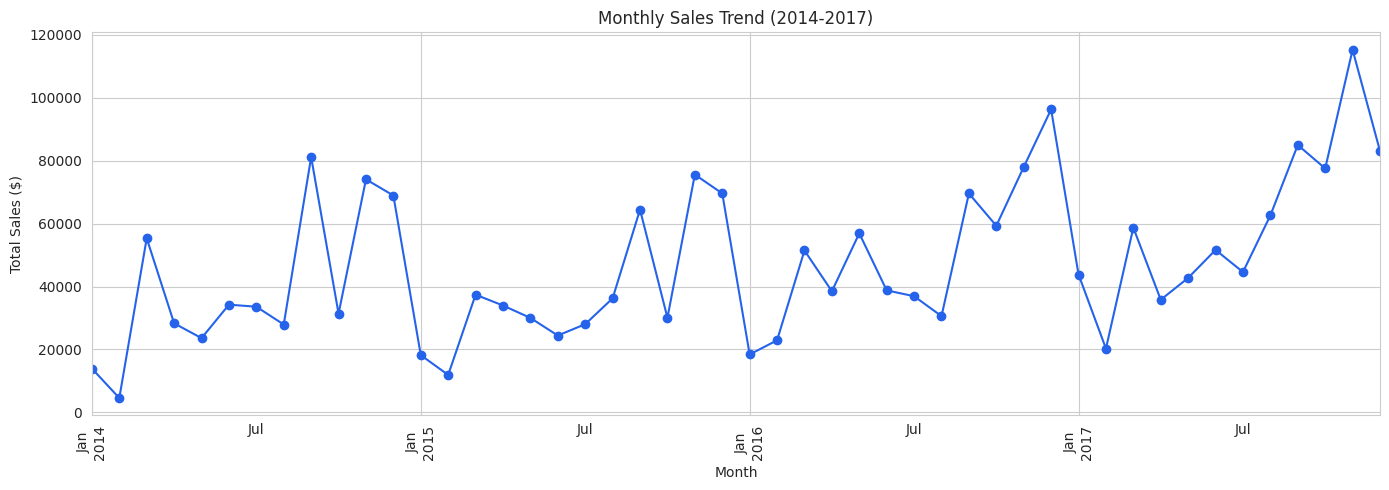

In [6]:
monthly_sales = df.groupby('Order Month')['Sales'].sum()

fig, ax = plt.subplots(figsize=(14,5))
monthly_sales.plot(ax=ax, marker='o', color='#2563eb')
ax.set_title('Monthly Sales Trend (2014-2017)')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('screenshots/01_monthly_sales_trend.png', dpi=120)
plt.show()

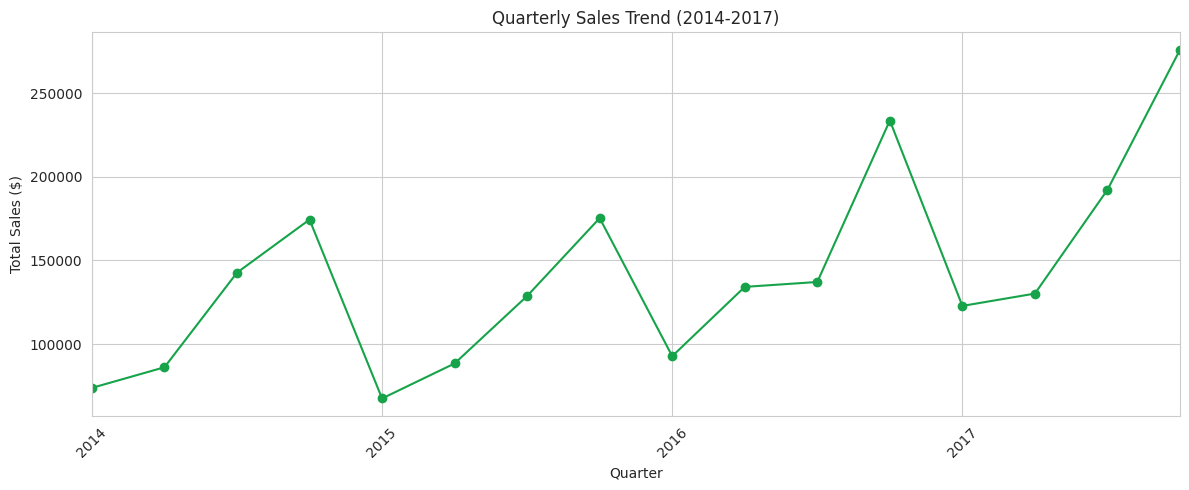

In [7]:
quarterly_sales = df.groupby('Order Quarter')['Sales'].sum()

fig, ax = plt.subplots(figsize=(12,5))
quarterly_sales.plot(kind='line', marker='o', ax=ax, color='#16a34a')
ax.set_title('Quarterly Sales Trend (2014-2017)')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('screenshots/02_quarterly_sales_trend.png', dpi=120)
plt.show()

Sales spike every Q4 (Nov-Dec), makes sense because of holiday shopping. Q1 is the weakest
quarter every single year.

## 4. Customer Demographics — Segment & Regional Breakdown

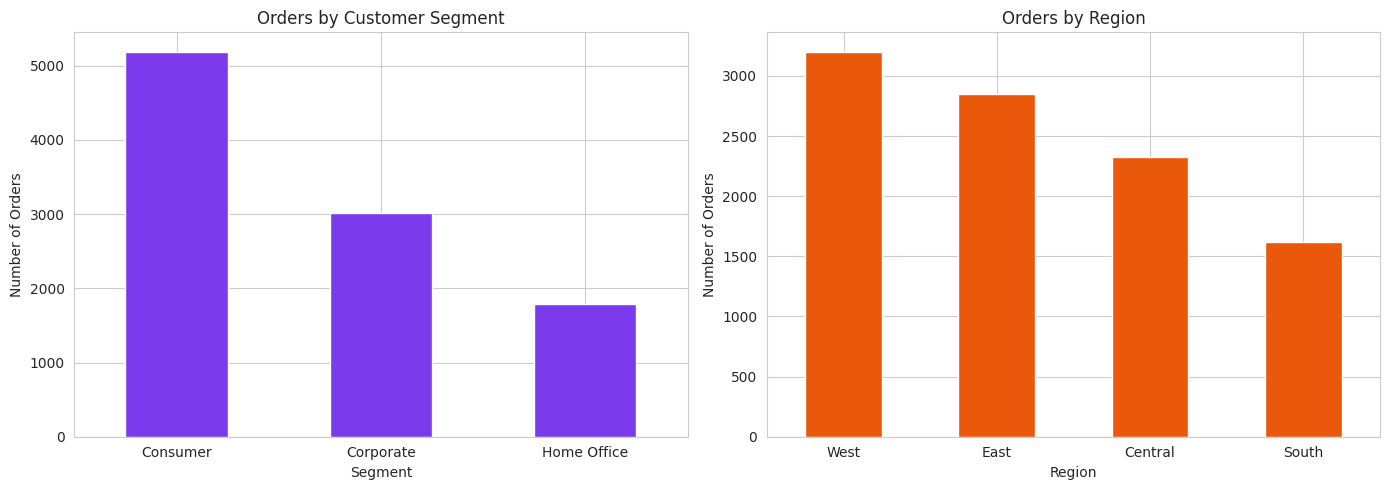

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

df['Segment'].value_counts().plot(kind='bar', ax=axes[0], color='#7c3aed')
axes[0].set_title('Orders by Customer Segment')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=0)

df['Region'].value_counts().plot(kind='bar', ax=axes[1], color='#ea580c')
axes[1].set_title('Orders by Region')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('screenshots/03_segment_region_breakdown.png', dpi=120)
plt.show()

Consumer segment is almost half of all orders, way more than Corporate or Home Office.
West and East regions have the most orders.

## 5. Product Analysis

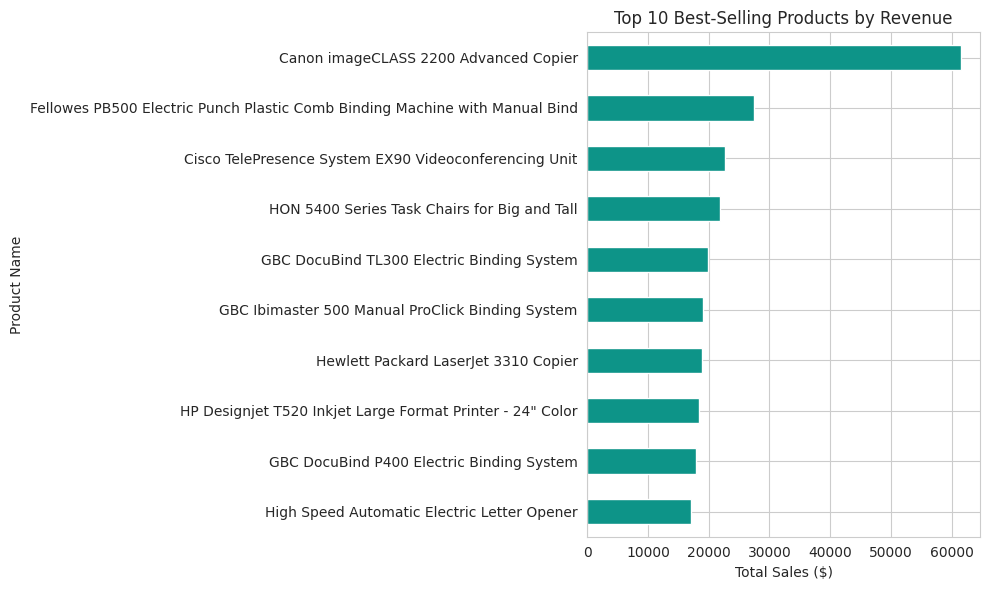

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [9]:
top10_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10,6))
top10_products.sort_values().plot(kind='barh', ax=ax, color='#0d9488')
ax.set_title('Top 10 Best-Selling Products by Revenue')
ax.set_xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('screenshots/04_top10_products.png', dpi=120)
plt.show()
top10_products

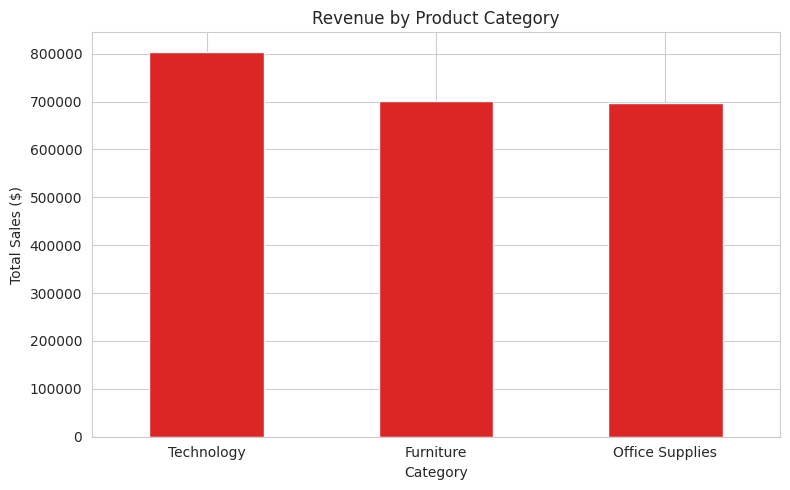

Category
Technology         804494.6100
Furniture          701370.6686
Office Supplies    696534.2130
Name: Sales, dtype: float64

In [10]:
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,5))
category_revenue.plot(kind='bar', ax=ax, color='#dc2626')
ax.set_title('Revenue by Product Category')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('screenshots/05_category_revenue.png', dpi=120)
plt.show()
category_revenue

Technology and Furniture bring in the most revenue by category. But (checked this in the
next section) high sales in Furniture doesn't mean high profit because of discounting.

## 6. Correlation Heatmap

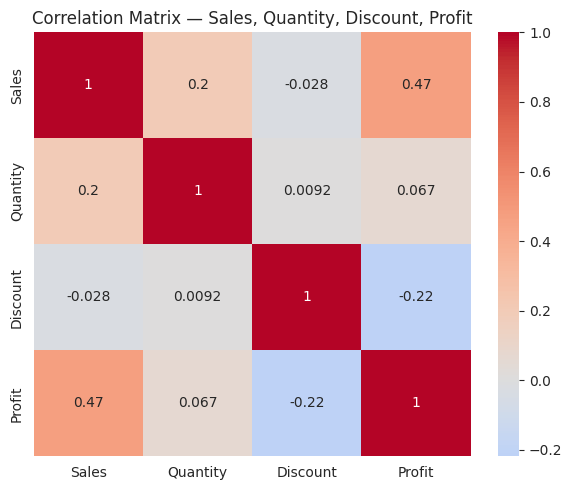

In [11]:
corr = df[['Sales','Quantity','Discount','Profit']].corr()

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix — Sales, Quantity, Discount, Profit')
plt.tight_layout()
plt.savefig('screenshots/06_correlation_heatmap.png', dpi=120)
plt.show()

Discount and Profit have a negative correlation (-0.22), so more discount = less profit,
which tracks. Sales and Profit are only weakly correlated, so more sales doesn't
automatically mean more profit.

## 7. Additional Insight — Discount vs Profit by Category

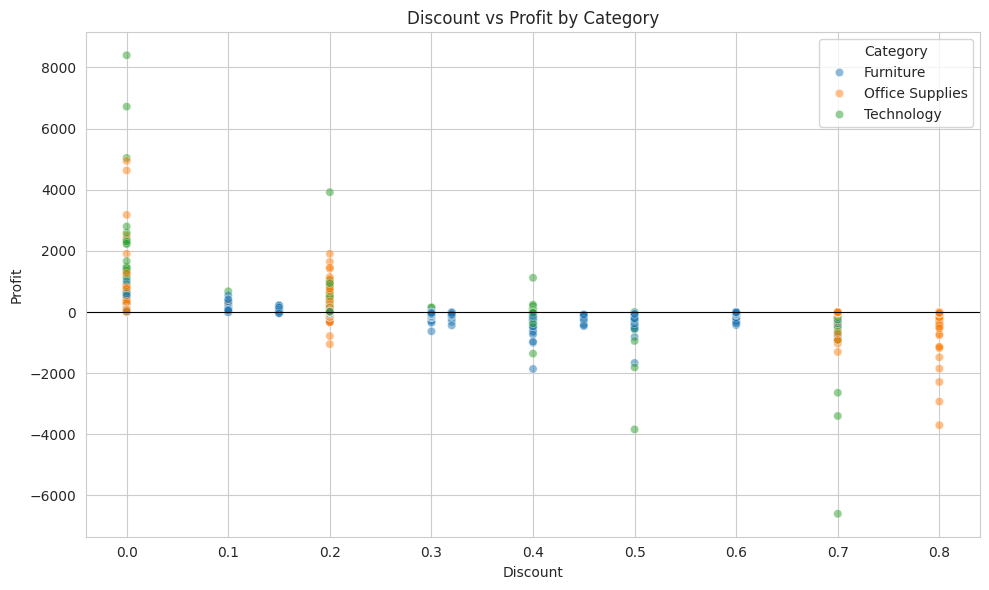

In [12]:
fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.5, ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Discount vs Profit by Category')
plt.tight_layout()
plt.savefig('screenshots/07_discount_vs_profit.png', dpi=120)
plt.show()

This one's more specific than the correlation number - once discount goes past ~30-40%,
Furniture and Technology orders start going into loss (below the 0 line on the chart). So
there's basically a discount limit that's getting crossed too often.

## 8. Conclusion / Recommendations

- Discounts above ~25% on Furniture and Technology are usually loss-making, so there should
  be some kind of cap or approval step before going higher than that.
- Q1 is weak every year, so instead of spending more on Q4 marketing (which is already doing
  well), it makes more sense to run a Q1 push like a January sale to fix the weak quarter.
- West and East regions have the most orders, so inventory/delivery should probably be
  prioritized there first.
- Consumer segment has the most orders but that doesn't necessarily mean it's the most
  profitable segment - would need to check profit per order by segment separately to confirm.